In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

In [6]:
df = pd.read_csv("heart.csv")

In [7]:
encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

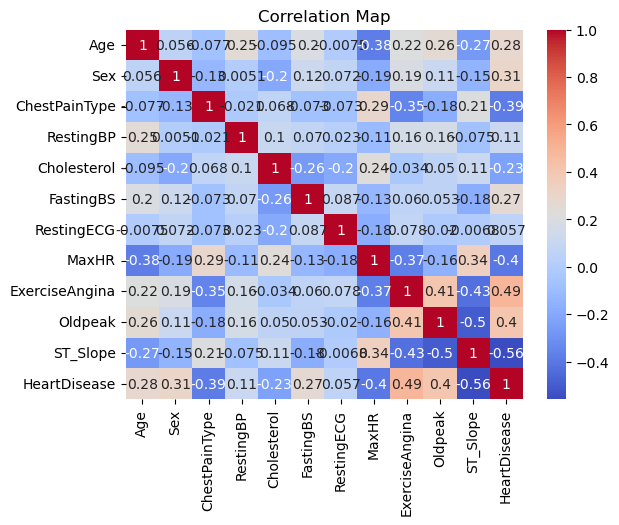

In [8]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Map")
plt.show()

In [9]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

model = GaussianNB()
model.fit(X, y)

print("Model Accuracy:", model.score(X, y))

Model Accuracy: 0.8583877995642701


In [11]:
print("\n--- Enter Patient Details ---")
user_input = []

for col in X.columns:
    val = input(f"Enter {col}: ")

    # Convert text inputs using the encoder, numbers to float
    if col in encoders:
        val = encoders[col].transform([val])[0]
    else:
        val = float(val)

    user_input.append(val)


--- Enter Patient Details ---


Enter Age:  15
Enter Sex:  M
Enter ChestPainType:  ATA
Enter RestingBP:  140
Enter Cholesterol:  280
Enter FastingBS:  0
Enter RestingECG:  Normal
Enter MaxHR:  170
Enter ExerciseAngina:  N
Enter Oldpeak:  0
Enter ST_Slope:  Up


In [12]:
prediction = model.predict([user_input])[0]

if prediction == 1:
    print("\nResult: Heart Disease Detected")
else:
    print("\nResult: Normal (No Heart Disease)")


Result: Normal (No Heart Disease)


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
